In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Advertising.csv")

df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [2]:
# Remove unnecessary index column
df = df.drop(columns=["Unnamed: 0"])

# Check dataset shape and information
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

Dataset Shape: (200, 4)

Column Names:
Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [3]:
print("Missing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

Missing Values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Statistical Summary:
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   14.022500
std     85.854236   14.846809   21.778621    5.217457
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   10.375000
50%    149.750000   22.900000   25.750000   12.900000
75%    218.825000   36.525000   45.100000   17.400000
max    296.400000   49.600000  114.000000   27.000000


In [4]:
# Correlation analysis
print("Correlation Matrix:")
print(df.corr())

Correlation Matrix:
                 TV     Radio  Newspaper     Sales
TV         1.000000  0.054809   0.056648  0.782224
Radio      0.054809  1.000000   0.354104  0.576223
Newspaper  0.056648  0.354104   1.000000  0.228299
Sales      0.782224  0.576223   0.228299  1.000000


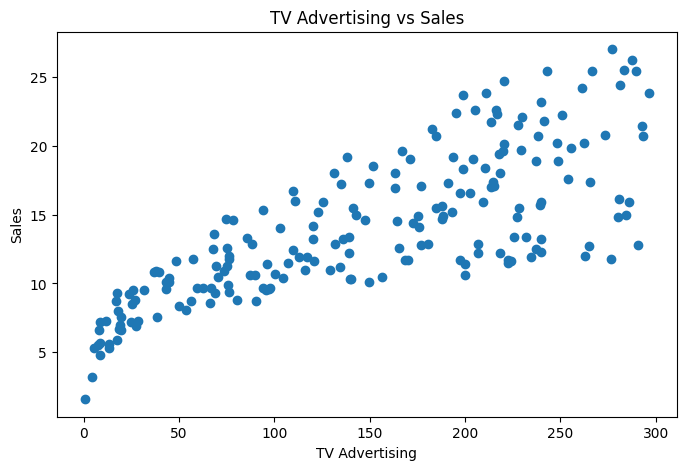

In [5]:
# Visualization: Advertising Channels vs Sales

plt.figure(figsize=(8, 5))
plt.scatter(df["TV"], df["Sales"])
plt.xlabel("TV Advertising")
plt.ylabel("Sales")
plt.title("TV Advertising vs Sales")
plt.show()

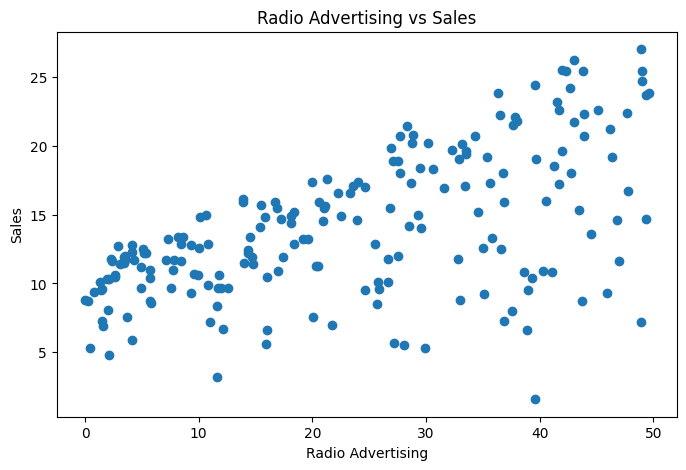

In [6]:
# Radio Advertising vs Sales

plt.figure(figsize=(8,5))
plt.scatter(df["Radio"], df["Sales"])
plt.xlabel("Radio Advertising")
plt.ylabel("Sales")
plt.title("Radio Advertising vs Sales")
plt.show()

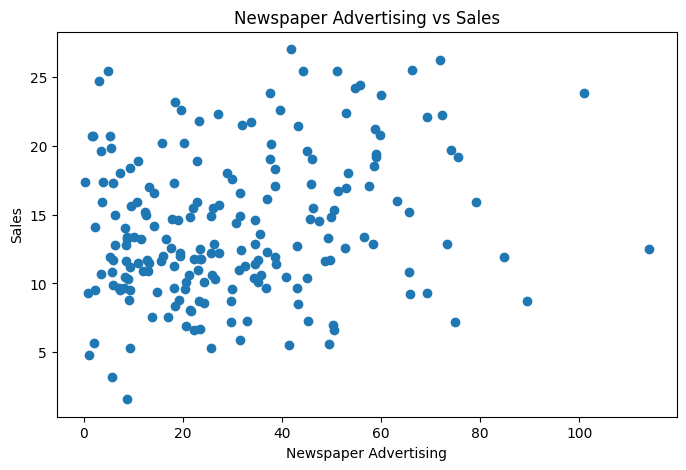

In [7]:
# Newspaper Advertising vs Sales

plt.figure(figsize=(8,5))
plt.scatter(df["Newspaper"], df["Sales"])
plt.xlabel("Newspaper Advertising")
plt.ylabel("Sales")
plt.title("Newspaper Advertising vs Sales")
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Features and target
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict sales
y_pred = model.predict(X_test)

# Model evaluation
print("R² Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

R² Score: 0.899438024100912
Mean Squared Error: 3.1740973539761033


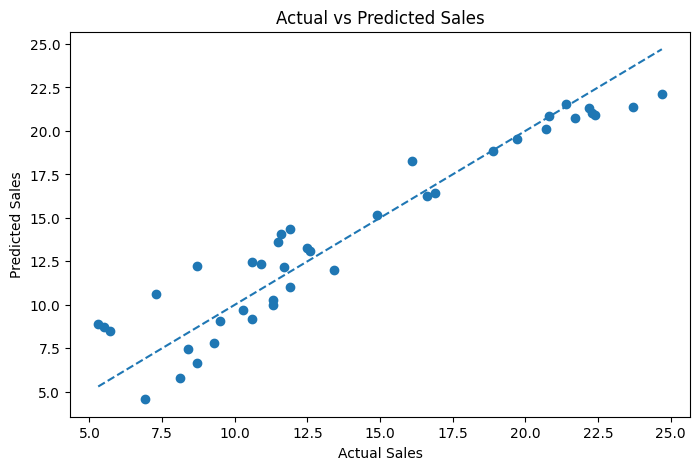

In [9]:
# Actual vs Predicted Sales

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

# Perfect prediction reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

In [10]:
# Example: Predict Sales for a New Advertising Budget

new_data = pd.DataFrame({
    "TV": [150],
    "Radio": [30],
    "Newspaper": [20]
})

predicted_sales = model.predict(new_data)

print("Predicted Sales:", predicted_sales[0])

Predicted Sales: 15.419568872288718


## Key Insights

- TV advertising has the strongest relationship with Sales.
- Radio advertising also shows a positive relationship with Sales.
- Newspaper advertising has a weaker relationship with Sales.
- The Linear Regression model achieved an R² score of approximately 0.90.
- Actual and predicted sales values are reasonably close, indicating good model performance.